In [1]:
import sys
from pathlib import Path
import torch
import numpy as np

script_dir = Path.cwd()
sys.path.insert(0, str(script_dir.parent.parent))

from config import PROJECT_ROOT, XLSR_DROPOUT, RANDOM_SEEDS
from model_DANN import AD_XLSR_Model_DANN
from dataset import FeatureDataset, create_dataloaders
from train_ST_DANN import train_st_dann_parallel, validate_dann
from visualization import plot_training_curves, plot_dataset_comparison

2026-01-16 15:38:08 | INFO | fairseq.tasks.text_to_speech | Please install tensorboardX: pip install tensorboardX


In [2]:
SOURCE_DATASET = "ADReSS"
TARGET_DATASET = "Lu"

# Model Selection Weights
SOURCE_WEIGHT = 0.5  # Weight for source domain validation accuracy
TARGET_WEIGHT = 0.5  # Weight for target domain validation accuracy

# Accuracy Thresholds
MIN_SOURCE_ACC = 0  # Minimum required source domain validation accuracy
MIN_TARGET_ACC = 0  # Minimum required target domain validation accuracy

# Training Hyperparameters
WARMUP_EPOCHS = 20              # Warmup phase epochs (DANN on source only)
MAX_ITERATIONS = 10              # Maximum ST iterations
MAX_EPOCHS_PER_ITER = 60        # Max epochs per ST iteration
CONFIDENCE_THRESHOLD = 0.9      # Pseudo-label confidence threshold
MIN_PSEUDO_SAMPLES = 5          # Minimum pseudo-labeled samples required

# DANN Hyperparameters
DOMAIN_WARMUP_EPOCHS = 30       # Domain loss warmup epochs (lambda=0)
DOMAIN_ANNEAL_RATIO = 0.25      # Proportion of epochs for annealing
LAMBDA_CLASS = 1.0              # Classification loss weight
LAMBDA_DOMAIN = 0.1             # Domain adversarial loss weight

# Device setup
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f"Device: {device}")

Device: cuda


In [3]:
data_dir = PROJECT_ROOT / "data" / "processed"

SOURCE_TRAIN_CSV = data_dir / f"{SOURCE_DATASET}-xlsr-train.csv"
SOURCE_VAL_CSV = data_dir / f"{SOURCE_DATASET}-xlsr-val.csv"
TARGET_TRAIN_CSV = data_dir / f"{TARGET_DATASET}-xlsr-train.csv"
TARGET_VAL_CSV = data_dir / f"{TARGET_DATASET}-xlsr-val.csv"

MODEL_OUTPUT_DIR = PROJECT_ROOT / "models" / f"ST_DANN_parallel_{SOURCE_DATASET}_to_{TARGET_DATASET}_xlsr_t{int(CONFIDENCE_THRESHOLD*100)}"
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Output: {MODEL_OUTPUT_DIR}")

Output: /root/autodl-tmp/models/ST_DANN_parallel_ADReSS_to_Lu_xlsr_t90


In [4]:
# Load datasets
source_train_dataset = FeatureDataset(SOURCE_TRAIN_CSV, xlsr=True)
target_train_dataset = FeatureDataset(TARGET_TRAIN_CSV, xlsr=True)

source_val_loader = create_dataloaders(SOURCE_VAL_CSV, xlsr=True)
target_val_loader = create_dataloaders(TARGET_VAL_CSV, xlsr=True)

Loading completed: 124 samples
Control: 62, Dementia: 62


Loading completed: 58 samples
Control: 28, Dementia: 30


Loading completed: 32 samples
Control: 16, Dementia: 16


Loading completed: 16 samples
Control: 8, Dementia: 8




In [5]:
def evaluate_and_visualize(seed, all_metrics, all_histories, all_pseudo_stats,
                           source_val_loader, target_val_loader, output_dir, device):
    """Evaluate best ST+DANN iteration and visualize results"""
    if not all_metrics:
        raise ValueError('all_metrics is empty; run training first.')
    
    # Find best iteration by avg_val_acc
    best_iter_idx = max(
        range(len(all_metrics)),
        key=lambda i: all_metrics[i].get('avg_val_acc', 0) if all_metrics[i] else 0
    )
    best_metric = all_metrics[best_iter_idx]
    
    print('='*60)
    print(f"Evaluating Best Model (Seed {seed})")
    print(f"Best Iteration: {best_iter_idx}")
    if best_metric:
        print(f"Best Avg Acc: {best_metric.get('avg_val_acc', 0)*100:.2f}%")
        print(f"  Source: {best_metric.get('source_val_acc', 0)*100:.2f}%")
        print(f"  Target: {best_metric.get('target_val_acc', 0)*100:.2f}%")
    print('='*60)
    
    model_path = output_dir / f"seed_{seed}" / f"st_dann_iter_{best_iter_idx}.pth"
    print(f"Loading model from: {model_path}")
    
    best_model = AD_XLSR_Model_DANN(dropout=XLSR_DROPOUT).to(device)
    best_model.load_state_dict(torch.load(model_path, map_location=device))
    
    source_loss, source_acc, source_control_acc, source_dementia_acc, source_f1 = validate_dann(
        best_model, source_val_loader, device
    )
    target_loss, target_acc, target_control_acc, target_dementia_acc, target_f1 = validate_dann(
        best_model, target_val_loader, device
    )
    
    print(f"\n{'Dataset':<25} {'Accuracy':<12} {'F1 Score':<12} {'Dementia':<12} {'Control':<12} {'Loss':<10}")
    print('-'*85)
    print(f"{f'{SOURCE_DATASET} (source domain)':<25} {source_acc*100:>10.2f}%  {source_f1:>10.4f}  {source_dementia_acc*100:>10.2f}%  {source_control_acc*100:>10.2f}%  {source_loss:>8.4f}")
    print(f"{f'{TARGET_DATASET} (target domain)':<25} {target_acc*100:>10.2f}%  {target_f1:>10.4f}  {target_dementia_acc*100:>10.2f}%  {target_control_acc*100:>10.2f}%  {target_loss:>8.4f}")
    print('-'*85)
    
    # Visualize
    dataset_names = [f'{SOURCE_DATASET} (source)', f'{TARGET_DATASET} (target)']
    accuracies = [source_acc * 100, target_acc * 100]
    plot_dataset_comparison(
        dataset_names=dataset_names,
        accuracies=accuracies,
        title=f'ST+DANN Parallel (Seed {seed}, Iter {best_iter_idx})',
        custom_colors={
            f'{SOURCE_DATASET} (source)': '#3498db',
            f'{TARGET_DATASET} (target)': '#e74c3c'
        }
    )
    
    source_metrics = {
        'acc': source_acc, 'f1': source_f1,
        'dementia_acc': source_dementia_acc,
        'control_acc': source_control_acc,
        'loss': source_loss
    }
    target_metrics = {
        'acc': target_acc, 'f1': target_f1,
        'dementia_acc': target_dementia_acc,
        'control_acc': target_control_acc,
        'loss': target_loss
    }
    return source_metrics, target_metrics

In [6]:
all_results = {
    'seeds': [],
    'metrics': [],
    'histories': [],
    'pseudo_stats': [],
    'source_metrics': [],
    'target_metrics': []
}

## Seed 21

In [7]:
seed, all_metrics, all_histories, all_pseudo_stats = train_st_dann_parallel(
    seed=21,
    source_train_dataset=source_train_dataset,  
    target_train_dataset=target_train_dataset,
    source_val_loader=source_val_loader,
    target_val_loader=target_val_loader,
    output_dir=MODEL_OUTPUT_DIR,
    device=device,
    warmup_epochs=WARMUP_EPOCHS,
    max_iterations=MAX_ITERATIONS,
    max_epochs_per_iter=MAX_EPOCHS_PER_ITER,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    min_pseudo_samples=MIN_PSEUDO_SAMPLES,
    domain_warmup_epochs=DOMAIN_WARMUP_EPOCHS,
    domain_anneal_ratio=DOMAIN_ANNEAL_RATIO,
    lambda_class=LAMBDA_CLASS,
    lambda_domain=LAMBDA_DOMAIN,
    source_weight=SOURCE_WEIGHT,
    target_weight=TARGET_WEIGHT,
    min_source_acc=MIN_SOURCE_ACC,
    min_target_acc=MIN_TARGET_ACC,
)

all_results['seeds'].append(seed)
all_results['metrics'].append(all_metrics)
all_results['histories'].append(all_histories)
all_results['pseudo_stats'].append(all_pseudo_stats)

# Find best iteration and plot training curves
best_iter_idx = max(range(len(all_metrics)), key=lambda i: all_metrics[i].get('avg_val_acc', 0) if all_metrics[i] else 0)
best_history = all_histories[best_iter_idx]


ST+DANN Parallel Training (Seed 21)
Loading completed: 124 samples
Control: 62, Dementia: 62


Loading completed: 58 samples
Control: 28, Dementia: 30



WARMUP: Training DANN on source only (20 epochs)


Epoch   1 | Train: 0.531 | Source Val: 0.500 | Target Val: 0.500 | Avg: 0.500 | Domain: 0.000 | λ_dom: 0.000


Epoch   2 | Train: 0.708 | Source Val: 0.625 | Target Val: 0.375 | Avg: 0.500 | Domain: 0.000 | λ_dom: 0.000


Epoch   3 | Train: 0.844 | Source Val: 0.594 | Target Val: 0.438 | Avg: 0.516 | Domain: 0.000 | λ_dom: 0.000


Epoch   4 | Train: 0.854 | Source Val: 0.656 | Target Val: 0.375 | Avg: 0.516 | Domain: 0.000 | λ_dom: 0.000


...

Epoch  20 | Train: 1.000 | Source Val: 0.781 | Target Val: 0.750 | Avg: 0.766 | Domain: 0.600 | λ_dom: 0.100


Epoch  21 | Train: 1.000 | Source Val: 0.750 | Target Val: 0.750 | Avg: 0.750 | Domain: 0.603 | λ_dom: 0.100


Epoch  22 | Train: 0.994 | Source Val: 0.656 | Target Val: 0.688 | Avg: 0.672 | Domain: 0.622 | λ_dom: 0.100


Epoch  23 | Train: 0.988 | Source Val: 0.656 | Target Val: 0.688 | Avg: 0.672 | Domain: 0.603 | λ_dom: 0.100


Epoch  24 | Train: 0.975 | Source Val: 0.781 | Target Val: 0.688 | Avg: 0.734 | Domain: 0.609 | λ_dom: 0.100
  Early stop at epoch 24
Iter 9 Best: Epoch 14 | Avg:76.56% | Src:78.12% | Tgt:75.00% | Pseudo:44

Best: Iter 0 | Avg:81.25% | Src:87.50% | Tgt:75.00%



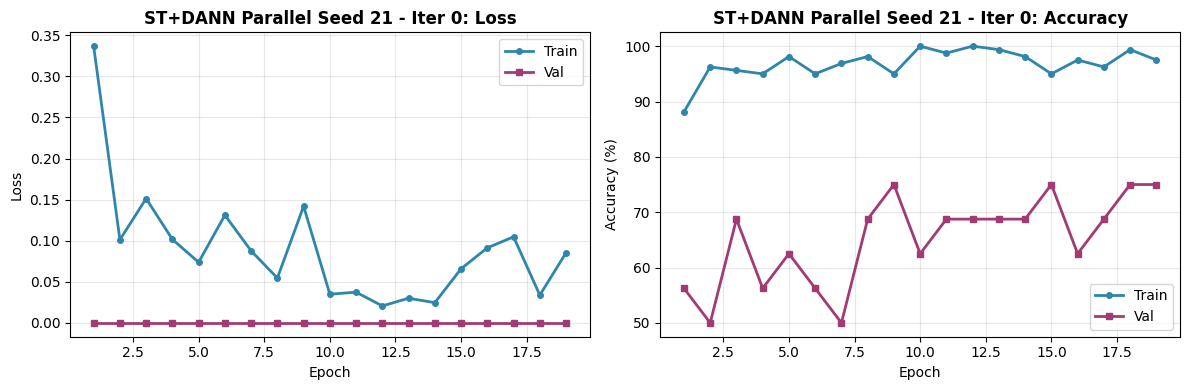

Evaluating Best Model (Seed 21)
Best Iteration: 0
Best Avg Acc: 81.25%
  Source: 87.50%
  Target: 75.00%
Loading model from: /root/autodl-tmp/models/ST_DANN_parallel_ADReSS_to_Lu_xlsr_t90/seed_21/st_dann_iter_0.pth

Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
ADReSS (source domain)         84.38%      0.8485       87.50%       81.25%    0.5475
Lu (target domain)             75.00%      0.7778       87.50%       62.50%    1.6384
-------------------------------------------------------------------------------------


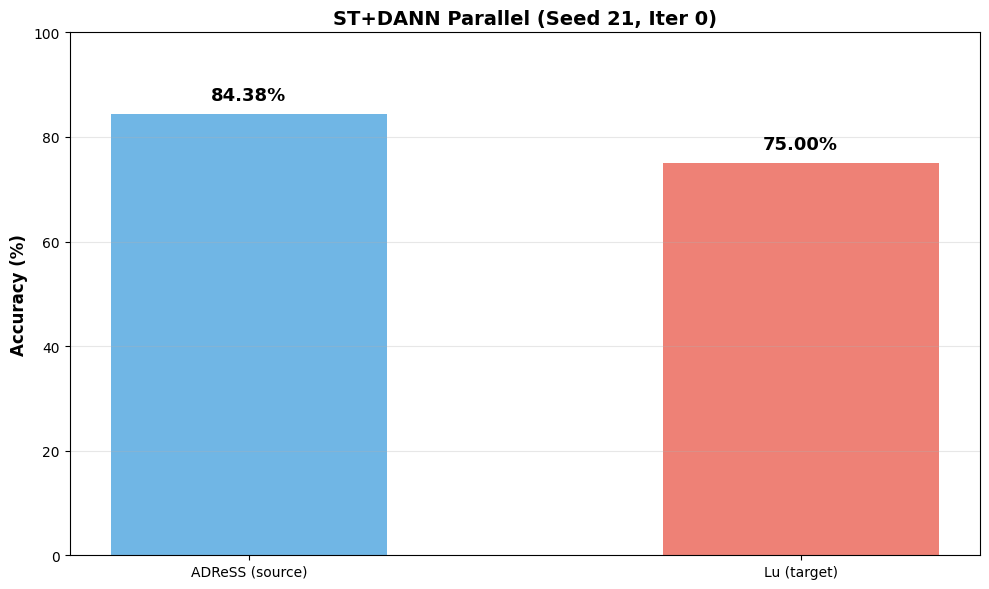

In [8]:
plot_training_curves(
    epochs=best_history['epochs'],
    train_loss=best_history['train_class_losses'],
    val_loss=[0]*len(best_history['epochs']),
    train_acc=best_history['train_accs'],
    val_acc=best_history['target_val_accs'],
    title_prefix=f'ST+DANN Parallel Seed {seed} - Iter {best_iter_idx}'
)

# Evaluate best model
source_metrics, target_metrics = evaluate_and_visualize(
    seed, all_metrics, all_histories, all_pseudo_stats,
    source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device
)

all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)

## Seed 42

In [9]:
seed, all_metrics, all_histories, all_pseudo_stats = train_st_dann_parallel(
    seed=42,
    source_train_dataset=source_train_dataset,
    target_train_dataset=target_train_dataset,
    source_val_loader=source_val_loader,
    target_val_loader=target_val_loader,
    output_dir=MODEL_OUTPUT_DIR,
    device=device,
    max_iterations=MAX_ITERATIONS,
    max_epochs_per_iter=MAX_EPOCHS_PER_ITER,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    min_pseudo_samples=MIN_PSEUDO_SAMPLES,
    domain_warmup_epochs=DOMAIN_WARMUP_EPOCHS,
    domain_anneal_ratio=DOMAIN_ANNEAL_RATIO,
    lambda_class=LAMBDA_CLASS,
    lambda_domain=LAMBDA_DOMAIN,
    source_weight=SOURCE_WEIGHT,
    target_weight=TARGET_WEIGHT,
    min_source_acc=MIN_SOURCE_ACC,
    min_target_acc=MIN_TARGET_ACC,
)

all_results['seeds'].append(seed)
all_results['metrics'].append(all_metrics)
all_results['histories'].append(all_histories)
all_results['pseudo_stats'].append(all_pseudo_stats)

# Find best iteration and plot training curves
best_iter_idx = max(range(len(all_metrics)), key=lambda i: all_metrics[i].get('avg_val_acc', 0) if all_metrics[i] else 0)
best_history = all_histories[best_iter_idx]


ST+DANN Parallel Training (Seed 42)


Loading completed: 124 samples
Control: 62, Dementia: 62


Loading completed: 58 samples
Control: 28, Dementia: 30



WARMUP: Training DANN on source only (20 epochs)


Epoch   1 | Train: 0.583 | Source Val: 0.500 | Target Val: 0.500 | Avg: 0.500 | Domain: 0.000 | λ_dom: 0.000


Epoch   2 | Train: 0.792 | Source Val: 0.500 | Target Val: 0.500 | Avg: 0.500 | Domain: 0.000 | λ_dom: 0.000


Epoch   3 | Train: 0.833 | Source Val: 0.500 | Target Val: 0.438 | Avg: 0.469 | Domain: 0.000 | λ_dom: 0.000


...

Epoch  11 | Train: 0.988 | Source Val: 0.719 | Target Val: 0.750 | Avg: 0.734 | Domain: 0.562 | λ_dom: 0.100


Epoch  12 | Train: 0.994 | Source Val: 0.719 | Target Val: 0.750 | Avg: 0.734 | Domain: 0.537 | λ_dom: 0.100


Epoch  13 | Train: 0.994 | Source Val: 0.750 | Target Val: 0.750 | Avg: 0.750 | Domain: 0.516 | λ_dom: 0.100


Epoch  14 | Train: 0.994 | Source Val: 0.781 | Target Val: 0.750 | Avg: 0.766 | Domain: 0.556 | λ_dom: 0.100


Epoch  15 | Train: 0.988 | Source Val: 0.719 | Target Val: 0.750 | Avg: 0.734 | Domain: 0.544 | λ_dom: 0.100
  Early stop at epoch 15
Iter 9 Best: Epoch 5 | Avg:79.69% | Src:78.12% | Tgt:81.25% | Pseudo:49

Best: Iter 0 | Avg:81.25% | Src:81.25% | Tgt:81.25%



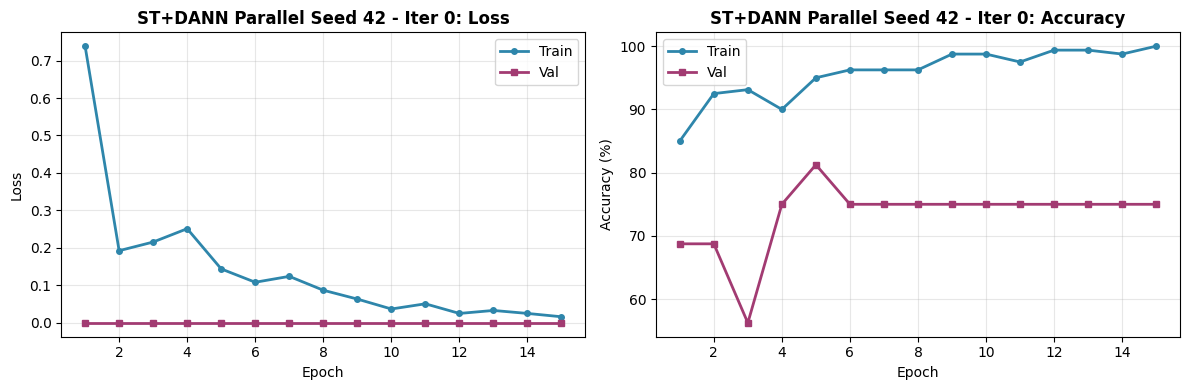

Evaluating Best Model (Seed 42)
Best Iteration: 0
Best Avg Acc: 81.25%
  Source: 81.25%
  Target: 81.25%
Loading model from: /root/autodl-tmp/models/ST_DANN_parallel_ADReSS_to_Lu_xlsr_t90/seed_42/st_dann_iter_0.pth

Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
ADReSS (source domain)         81.25%      0.7857       68.75%       93.75%    0.5261
Lu (target domain)             81.25%      0.8235       87.50%       75.00%    0.7922
-------------------------------------------------------------------------------------


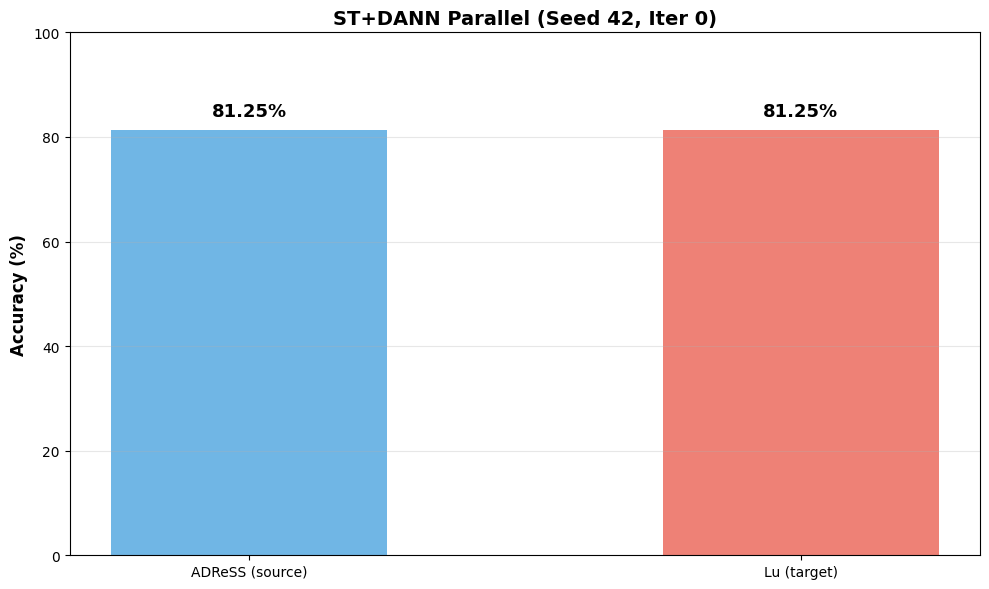

In [10]:
plot_training_curves(
    epochs=best_history['epochs'],
    train_loss=best_history['train_class_losses'],
    val_loss=[0]*len(best_history['epochs']),
    train_acc=best_history['train_accs'],
    val_acc=best_history['target_val_accs'],
    title_prefix=f'ST+DANN Parallel Seed {seed} - Iter {best_iter_idx}'
)

# Evaluate best model
source_metrics, target_metrics = evaluate_and_visualize(
    seed, all_metrics, all_histories, all_pseudo_stats,
    source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device
)

all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)

## Seed 84

In [11]:
seed, all_metrics, all_histories, all_pseudo_stats = train_st_dann_parallel(
    seed=84,
    source_train_dataset=source_train_dataset,
    target_train_dataset=target_train_dataset,
    source_val_loader=source_val_loader,
    target_val_loader=target_val_loader,
    output_dir=MODEL_OUTPUT_DIR,
    device=device,
    max_iterations=MAX_ITERATIONS,
    max_epochs_per_iter=MAX_EPOCHS_PER_ITER,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    min_pseudo_samples=MIN_PSEUDO_SAMPLES,
    domain_warmup_epochs=DOMAIN_WARMUP_EPOCHS,
    domain_anneal_ratio=DOMAIN_ANNEAL_RATIO,
    lambda_class=LAMBDA_CLASS,
    lambda_domain=LAMBDA_DOMAIN,
    source_weight=SOURCE_WEIGHT,
    target_weight=TARGET_WEIGHT,
    min_source_acc=MIN_SOURCE_ACC,
    min_target_acc=MIN_TARGET_ACC,
)

all_results['seeds'].append(seed)
all_results['metrics'].append(all_metrics)
all_results['histories'].append(all_histories)
all_results['pseudo_stats'].append(all_pseudo_stats)

# Find best iteration and plot training curves
best_iter_idx = max(range(len(all_metrics)), key=lambda i: all_metrics[i].get('avg_val_acc', 0) if all_metrics[i] else 0)
best_history = all_histories[best_iter_idx]


ST+DANN Parallel Training (Seed 84)
Loading completed: 124 samples
Control: 62, Dementia: 62


Loading completed: 58 samples
Control: 28, Dementia: 30



WARMUP: Training DANN on source only (20 epochs)


Epoch   1 | Train: 0.531 | Source Val: 0.500 | Target Val: 0.500 | Avg: 0.500 | Domain: 0.000 | λ_dom: 0.000


Epoch   2 | Train: 0.750 | Source Val: 0.562 | Target Val: 0.438 | Avg: 0.500 | Domain: 0.000 | λ_dom: 0.000


Epoch   3 | Train: 0.844 | Source Val: 0.594 | Target Val: 0.438 | Avg: 0.516 | Domain: 0.000 | λ_dom: 0.000


Epoch   4 | Train: 0.844 | Source Val: 0.750 | Target Val: 0.500 | Avg: 0.625 | Domain: 0.000 | λ_dom: 0.000


...

Epoch  11 | Train: 0.950 | Source Val: 0.688 | Target Val: 0.562 | Avg: 0.625 | Domain: 0.491 | λ_dom: 0.100


Epoch  12 | Train: 0.956 | Source Val: 0.781 | Target Val: 0.562 | Avg: 0.672 | Domain: 0.491 | λ_dom: 0.100


Epoch  13 | Train: 0.975 | Source Val: 0.719 | Target Val: 0.562 | Avg: 0.641 | Domain: 0.550 | λ_dom: 0.100


Epoch  14 | Train: 0.969 | Source Val: 0.688 | Target Val: 0.625 | Avg: 0.656 | Domain: 0.512 | λ_dom: 0.100


Epoch  15 | Train: 0.969 | Source Val: 0.750 | Target Val: 0.625 | Avg: 0.688 | Domain: 0.525 | λ_dom: 0.100
  Early stop at epoch 15
Iter 9 Best: Epoch 5 | Avg:70.31% | Src:78.12% | Tgt:62.50% | Pseudo:46

Best: Iter 0 | Avg:75.00% | Src:81.25% | Tgt:68.75%



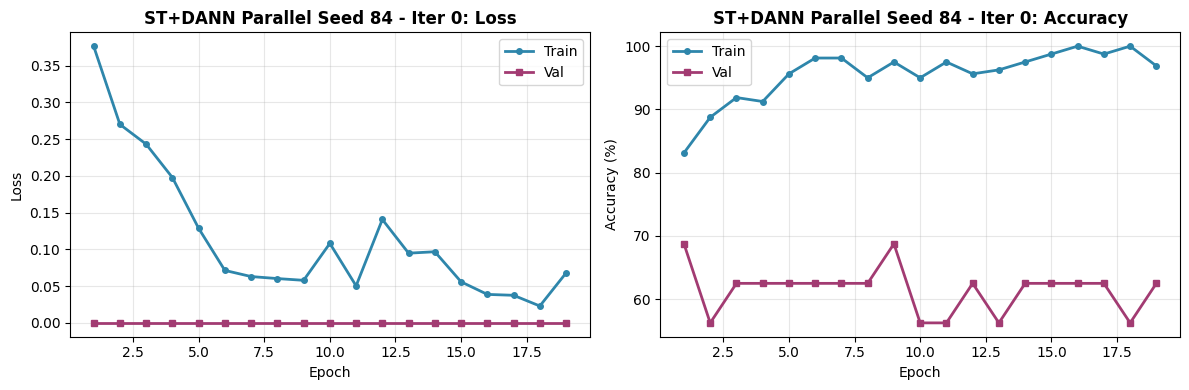

Evaluating Best Model (Seed 84)
Best Iteration: 0
Best Avg Acc: 75.00%
  Source: 81.25%
  Target: 68.75%
Loading model from: /root/autodl-tmp/models/ST_DANN_parallel_ADReSS_to_Lu_xlsr_t90/seed_84/st_dann_iter_0.pth

Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
ADReSS (source domain)         81.25%      0.8235       87.50%       75.00%    0.6718
Lu (target domain)             68.75%      0.7368       87.50%       50.00%    2.3644
-------------------------------------------------------------------------------------


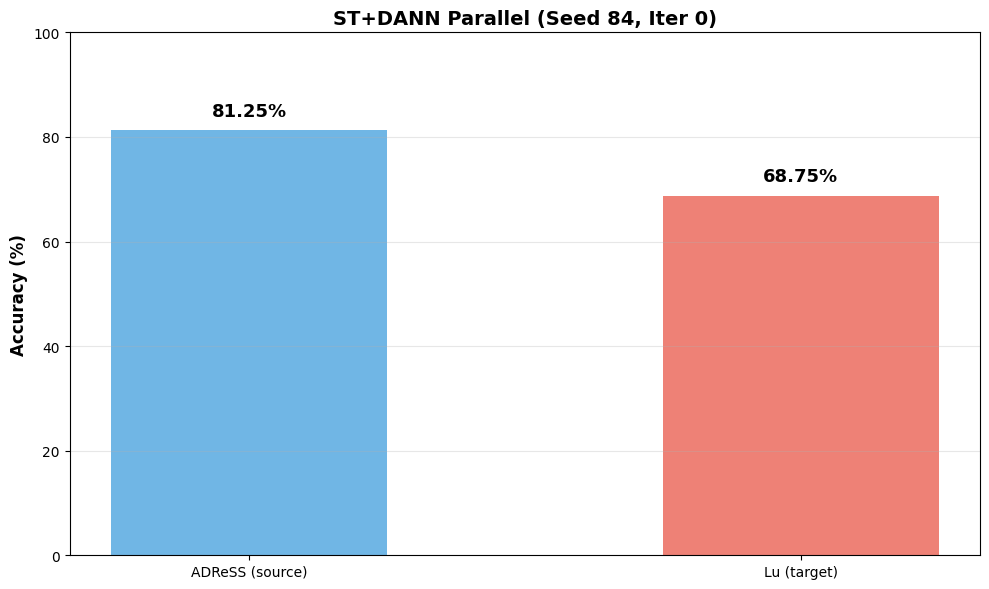

In [12]:
plot_training_curves(
    epochs=best_history['epochs'],
    train_loss=best_history['train_class_losses'],
    val_loss=[0]*len(best_history['epochs']),
    train_acc=best_history['train_accs'],
    val_acc=best_history['target_val_accs'],
    title_prefix=f'ST+DANN Parallel Seed {seed} - Iter {best_iter_idx}'
)

# Evaluate best model
source_metrics, target_metrics = evaluate_and_visualize(
    seed, all_metrics, all_histories, all_pseudo_stats,
    source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device
)

all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)

## Seed 168

In [13]:
seed, all_metrics, all_histories, all_pseudo_stats = train_st_dann_parallel(
    seed=168,
    source_train_dataset=source_train_dataset,
    target_train_dataset=target_train_dataset,
    source_val_loader=source_val_loader,
    target_val_loader=target_val_loader,
    output_dir=MODEL_OUTPUT_DIR,
    device=device,
    max_iterations=MAX_ITERATIONS,
    max_epochs_per_iter=MAX_EPOCHS_PER_ITER,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    min_pseudo_samples=MIN_PSEUDO_SAMPLES,
    domain_warmup_epochs=DOMAIN_WARMUP_EPOCHS,
    domain_anneal_ratio=DOMAIN_ANNEAL_RATIO,
    lambda_class=LAMBDA_CLASS,
    lambda_domain=LAMBDA_DOMAIN,
    source_weight=SOURCE_WEIGHT,
    target_weight=TARGET_WEIGHT,
    min_source_acc=MIN_SOURCE_ACC,
    min_target_acc=MIN_TARGET_ACC,
)

all_results['seeds'].append(seed)
all_results['metrics'].append(all_metrics)
all_results['histories'].append(all_histories)
all_results['pseudo_stats'].append(all_pseudo_stats)

# Find best iteration and plot training curves
best_iter_idx = max(range(len(all_metrics)), key=lambda i: all_metrics[i].get('avg_val_acc', 0) if all_metrics[i] else 0)
best_history = all_histories[best_iter_idx]


ST+DANN Parallel Training (Seed 168)
Loading completed: 124 samples
Control: 62, Dementia: 62


Loading completed: 58 samples
Control: 28, Dementia: 30



WARMUP: Training DANN on source only (20 epochs)


Epoch   1 | Train: 0.583 | Source Val: 0.500 | Target Val: 0.500 | Avg: 0.500 | Domain: 0.000 | λ_dom: 0.000


Epoch   2 | Train: 0.698 | Source Val: 0.469 | Target Val: 0.250 | Avg: 0.359 | Domain: 0.000 | λ_dom: 0.000


Epoch   3 | Train: 0.865 | Source Val: 0.562 | Target Val: 0.312 | Avg: 0.438 | Domain: 0.000 | λ_dom: 0.000


Epoch   4 | Train: 0.844 | Source Val: 0.688 | Target Val: 0.312 | Avg: 0.500 | Domain: 0.000 | λ_dom: 0.000


...

Epoch  17 | Train: 0.984 | Source Val: 0.750 | Target Val: 0.688 | Avg: 0.719 | Domain: 0.453 | λ_dom: 0.100


Epoch  18 | Train: 0.977 | Source Val: 0.781 | Target Val: 0.688 | Avg: 0.734 | Domain: 0.527 | λ_dom: 0.100


Epoch  19 | Train: 0.992 | Source Val: 0.719 | Target Val: 0.688 | Avg: 0.703 | Domain: 0.551 | λ_dom: 0.100


Epoch  20 | Train: 0.977 | Source Val: 0.781 | Target Val: 0.688 | Avg: 0.734 | Domain: 0.547 | λ_dom: 0.100


Epoch  21 | Train: 0.984 | Source Val: 0.688 | Target Val: 0.688 | Avg: 0.688 | Domain: 0.527 | λ_dom: 0.100
  Early stop at epoch 21
Iter 9 Best: Epoch 11 | Avg:73.44% | Src:78.12% | Tgt:68.75% | Pseudo:34

Best: Iter 0 | Avg:78.12% | Src:87.50% | Tgt:68.75%



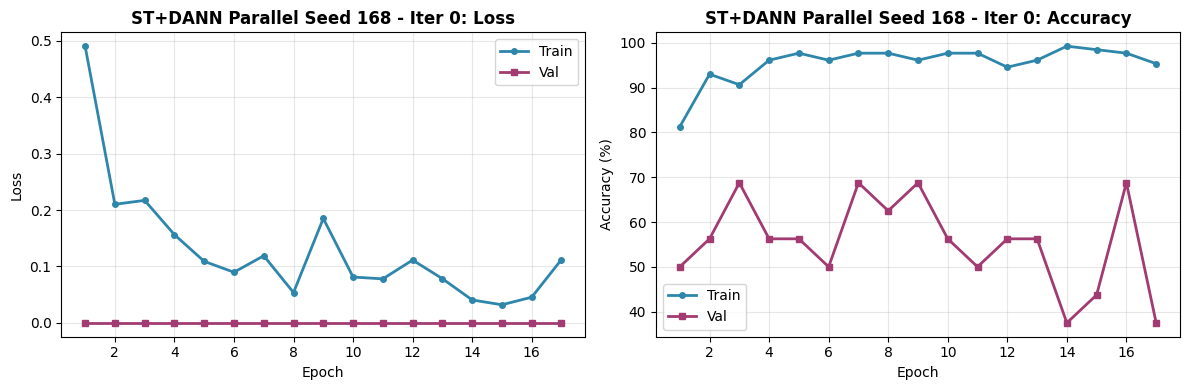

Evaluating Best Model (Seed 168)
Best Iteration: 0
Best Avg Acc: 78.12%
  Source: 87.50%
  Target: 68.75%
Loading model from: /root/autodl-tmp/models/ST_DANN_parallel_ADReSS_to_Lu_xlsr_t90/seed_168/st_dann_iter_0.pth

Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
ADReSS (source domain)         87.50%      0.8750       87.50%       87.50%    0.5106
Lu (target domain)             68.75%      0.7368       87.50%       50.00%    1.5225
-------------------------------------------------------------------------------------


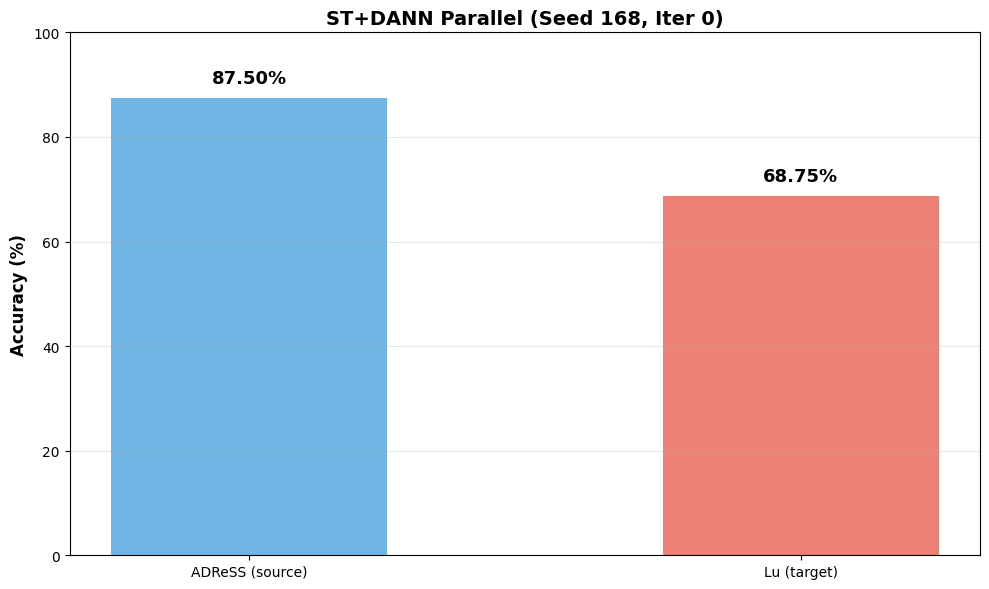

In [14]:

plot_training_curves(
    epochs=best_history['epochs'],
    train_loss=best_history['train_class_losses'],
    val_loss=[0]*len(best_history['epochs']),
    train_acc=best_history['train_accs'],
    val_acc=best_history['target_val_accs'],
    title_prefix=f'ST+DANN Parallel Seed {seed} - Iter {best_iter_idx}'
)

# Evaluate best model
source_metrics, target_metrics = evaluate_and_visualize(
    seed, all_metrics, all_histories, all_pseudo_stats,
    source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device
)

all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)

## Seed 336

In [15]:
seed, all_metrics, all_histories, all_pseudo_stats = train_st_dann_parallel(
    seed=336,
    source_train_dataset=source_train_dataset,
    target_train_dataset=target_train_dataset,
    source_val_loader=source_val_loader,
    target_val_loader=target_val_loader,
    output_dir=MODEL_OUTPUT_DIR,
    device=device,
    max_iterations=MAX_ITERATIONS,
    max_epochs_per_iter=MAX_EPOCHS_PER_ITER,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    min_pseudo_samples=MIN_PSEUDO_SAMPLES,
    domain_warmup_epochs=DOMAIN_WARMUP_EPOCHS,
    domain_anneal_ratio=DOMAIN_ANNEAL_RATIO,
    lambda_class=LAMBDA_CLASS,
    lambda_domain=LAMBDA_DOMAIN,
    source_weight=SOURCE_WEIGHT,
    target_weight=TARGET_WEIGHT,
    min_source_acc=MIN_SOURCE_ACC,
    min_target_acc=MIN_TARGET_ACC,
)

all_results['seeds'].append(seed)
all_results['metrics'].append(all_metrics)
all_results['histories'].append(all_histories)
all_results['pseudo_stats'].append(all_pseudo_stats)

# Find best iteration and plot training curves
best_iter_idx = max(range(len(all_metrics)), key=lambda i: all_metrics[i].get('avg_val_acc', 0) if all_metrics[i] else 0)
best_history = all_histories[best_iter_idx]


ST+DANN Parallel Training (Seed 336)
Loading completed: 124 samples
Control: 62, Dementia: 62


Loading completed: 58 samples
Control: 28, Dementia: 30



WARMUP: Training DANN on source only (20 epochs)


Epoch   1 | Train: 0.615 | Source Val: 0.500 | Target Val: 0.500 | Avg: 0.500 | Domain: 0.000 | λ_dom: 0.000


Epoch   2 | Train: 0.833 | Source Val: 0.562 | Target Val: 0.438 | Avg: 0.500 | Domain: 0.000 | λ_dom: 0.000


Epoch   3 | Train: 0.865 | Source Val: 0.656 | Target Val: 0.312 | Avg: 0.484 | Domain: 0.000 | λ_dom: 0.000


Epoch   4 | Train: 0.906 | Source Val: 0.656 | Target Val: 0.375 | Avg: 0.516 | Domain: 0.000 | λ_dom: 0.000


...

Epoch  26 | Train: 0.994 | Source Val: 0.750 | Target Val: 0.562 | Avg: 0.656 | Domain: 0.678 | λ_dom: 0.100


Epoch  27 | Train: 1.000 | Source Val: 0.781 | Target Val: 0.562 | Avg: 0.672 | Domain: 0.616 | λ_dom: 0.100


Epoch  28 | Train: 1.000 | Source Val: 0.781 | Target Val: 0.562 | Avg: 0.672 | Domain: 0.594 | λ_dom: 0.100


Epoch  29 | Train: 1.000 | Source Val: 0.781 | Target Val: 0.500 | Avg: 0.641 | Domain: 0.644 | λ_dom: 0.100


Epoch  30 | Train: 1.000 | Source Val: 0.750 | Target Val: 0.500 | Avg: 0.625 | Domain: 0.597 | λ_dom: 0.100
  Early stop at epoch 30
Iter 9 Best: Epoch 20 | Avg:68.75% | Src:75.00% | Tgt:62.50% | Pseudo:39

Best: Iter 2 | Avg:75.00% | Src:75.00% | Tgt:75.00%



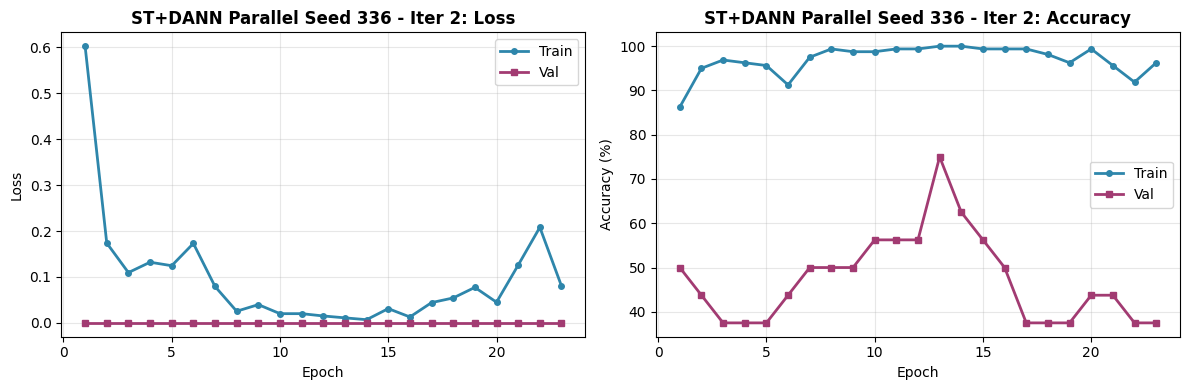

Evaluating Best Model (Seed 336)
Best Iteration: 2
Best Avg Acc: 75.00%
  Source: 75.00%
  Target: 75.00%
Loading model from: /root/autodl-tmp/models/ST_DANN_parallel_ADReSS_to_Lu_xlsr_t90/seed_336/st_dann_iter_2.pth

Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
ADReSS (source domain)         75.00%      0.7778       87.50%       62.50%    0.9954
Lu (target domain)             75.00%      0.7500       75.00%       75.00%    2.5182
-------------------------------------------------------------------------------------


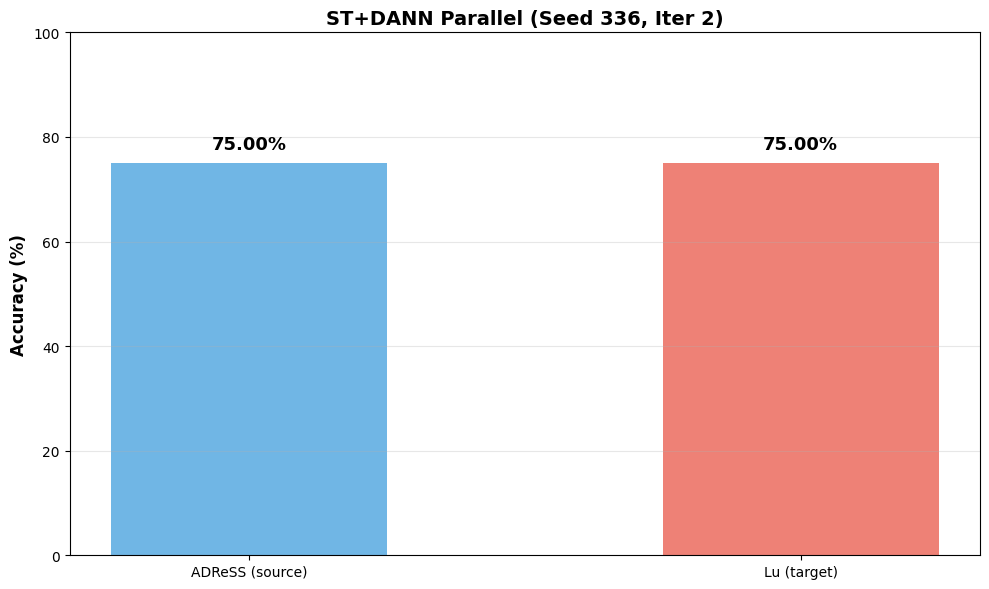

In [16]:

plot_training_curves(
    epochs=best_history['epochs'],
    train_loss=best_history['train_class_losses'],
    val_loss=[0]*len(best_history['epochs']),
    train_acc=best_history['train_accs'],
    val_acc=best_history['target_val_accs'],
    title_prefix=f'ST+DANN Parallel Seed {seed} - Iter {best_iter_idx}'
)

# Evaluate best model
source_metrics, target_metrics = evaluate_and_visualize(
    seed, all_metrics, all_histories, all_pseudo_stats,
    source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device
)

all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)

In [17]:
seeds = all_results['seeds']

# Source domain results
source_accs = [m['acc'] * 100 for m in all_results['source_metrics']]
source_f1s = [m['f1'] for m in all_results['source_metrics']]
source_dementia_accs = [m['dementia_acc'] * 100 for m in all_results['source_metrics']]
source_control_accs = [m['control_acc'] * 100 for m in all_results['source_metrics']]
source_losses = [m['loss'] for m in all_results['source_metrics']]

# Target domain results
target_accs = [m['acc'] * 100 for m in all_results['target_metrics']]
target_f1s = [m['f1'] for m in all_results['target_metrics']]
target_dementia_accs = [m['dementia_acc'] * 100 for m in all_results['target_metrics']]
target_control_accs = [m['control_acc'] * 100 for m in all_results['target_metrics']]
target_losses = [m['loss'] for m in all_results['target_metrics']]

print(f"{'Dataset':<25} {'Mean Acc':<20} {'Mean F1':<20} {'Mean Loss':<15}")
print(f"{'-'*90}")
print(f"{f'{SOURCE_DATASET} (source domain)':<25} {np.mean(source_accs):>6.2f}% ± {np.std(source_accs):>4.2f}%  {np.mean(source_f1s):>8.4f} ± {np.std(source_f1s):>6.4f}  {np.mean(source_losses):>10.4f}")
print(f"{f'{TARGET_DATASET} (target domain)':<25} {np.mean(target_accs):>6.2f}% ± {np.std(target_accs):>4.2f}%  {np.mean(target_f1s):>8.4f} ± {np.std(target_f1s):>6.4f}  {np.mean(target_losses):>10.4f}")
print(f"{'-'*90}\n")

print(f"{'Seed':<8} {'Dataset':<25} {'Accuracy':<12} {'F1 Score':<12} {'Dementia':<12} {'Control':<12} {'Loss':<10}")
print(f"{'-'*90}")
for i, seed in enumerate(seeds):
    print(f"{seed:<8} {f'{SOURCE_DATASET} (source domain)':<25} {source_accs[i]:>10.2f}%  {source_f1s[i]:>10.4f}  {source_dementia_accs[i]:>10.2f}%  {source_control_accs[i]:>10.2f}%  {source_losses[i]:>8.4f}")
    print(f"{'':8} {f'{TARGET_DATASET} (target domain)':<25} {target_accs[i]:>10.2f}%  {target_f1s[i]:>10.4f}  {target_dementia_accs[i]:>10.2f}%  {target_control_accs[i]:>10.2f}%  {target_losses[i]:>8.4f}")
    print(f"{'-'*90}")

Dataset                   Mean Acc             Mean F1              Mean Loss      
------------------------------------------------------------------------------------------
ADReSS (source domain)     81.88% ± 4.15%    0.8221 ± 0.0368      0.6503
Lu (target domain)         73.75% ± 4.68%    0.7650 ± 0.0329      1.7671
------------------------------------------------------------------------------------------

Seed     Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
------------------------------------------------------------------------------------------
21       ADReSS (source domain)         84.38%      0.8485       87.50%       81.25%    0.5475
         Lu (target domain)             75.00%      0.7778       87.50%       62.50%    1.6384
------------------------------------------------------------------------------------------
42       ADReSS (source domain)         81.25%      0.7857       68.75%       93.75%    0.5261
         Lu (target do